In [1]:
%pip install -U google-generativeai 
%pip install google-ai-generativelanguage==0.6.15
%pip install -U langchain-google-genai 
%pip install -U langchain-community
%pip install -U langgraph
%pip install -U langgraph langchain-community
%pip install python-dotenv



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.1.3
    Uninstalling langgraph-1.1.3:
      Successfully uninstalled langgraph-1.1.3

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you ma

In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator 

import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_core.messages import BaseMessage

from langchain_community.tools.tavily_search import TavilySearchResults

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/l2/t02s0r_51x727q8t6t5_qbp40000gn/T/ipykernel_61359/1442212385.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [3]:
import os 
from dotenv import load_dotenv  
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GEMINI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [4]:
tool = TavilySearchResults(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


/var/folders/l2/t02s0r_51x727q8t6t5_qbp40000gn/T/ipykernel_61359/1287549681.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4)


In [5]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [9]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name:t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self,state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0 
    
    def call_gemini(self,state: AgentState):
        messages = state ['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return{'messages': [messages]}
    
    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:
                print("\n....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t['name']].invoke(t['args'])                
    
    

In [10]:
prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

abot = Agent(model, [tool], system=prompt)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [11]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



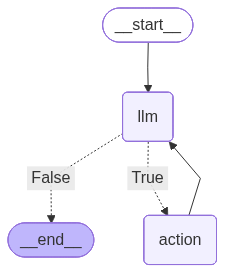

In [12]:
from IPython.display import Image, display

try: 
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))

except Exception as e:
    print(f"Erro ao gerar imagem PNG do Mermaid: {e}")
    print("\nCertifique-se de que a sua versão do LangGraph possui o método `.dra_mermaid_png()`.")
    print("Como alternativa, use `draw_mermaid()` para obter a string e visualizar externamente.")

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

model_instance = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tool_instance = TavilySearchResults(max_results=4)

abot = Agent(model_instance, [tool_instance], system=prompt)

messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")]

print("Iniciando interação do agente:")
final_result_state = None

for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

In [ ]:
messages = [HumanMessage(content="Quem é o presidente do Brasil?")] 
result = abot.graph.invoke({"messages": messages})

result 